Esse notebook tem o objetivo de comparar o range dos valores de porosidade esperados (de acordo com o notebook wells_viz) e o obtido após o processamento dos arquivos disponíveis de cada poço.

In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import pandas as pd
import pathlib

# Carregando dados gerais dos poços

In [2]:
all_wells_info_path = pathlib.Path("wells_info_completed.csv")
all_wells_info = pd.read_csv(all_wells_info_path)
all_wells_info.head()

,Well,x_coord,y_coord,min_y,max_y,type,min_y_adjusted,max_y_adjusted,test_area
0,2-ANP-1-RJS,677,1722,5400,5880,bottom,1080,1176,NaN
1,3-BRSA-1064-RJS,652,1114,5000,5930,bottom,1000,1186,NaN
2,3-BRSA-1184-RJS,855,1230,5400,5900,bottom,1080,1180,1.0
3,3-BRSA-1195-RJS,1041,2322,5450,5900,bottom,1090,1180,NaN
4,7-BUZ-10-RJS,415,392,5300,5780,bottom,1060,1156,3.0


# Carregando dados obtidos dos poços

In [18]:
wells_porosity_folder = pathlib.Path("../../../../../../data/ANP/raw/wells_porosity/")
all_porosities = wells_porosity_folder.glob("*.txt")
path_per_well = dict()
for porosity_file in all_porosities:
    well_name = porosity_file.stem 
    path_per_well[well_name] = porosity_file.resolve()

In [19]:
len(path_per_well)

18

In [20]:
df_per_well = dict()
column_names = ['depth', 'neutron_por', 'density_por', 'sonic_por']
for well_name, por_path in path_per_well.items():
    df = pd.read_csv(por_path, sep=' ', header=None, names=column_names)
    df_per_well[well_name] = df

In [21]:
expected_wells_names = all_wells_info['Well'].to_list()
for well_name in path_per_well.keys():
    if well_name not in expected_wells_names:
        print(well_name)

3-BRSA-1053-RJS


O poço 3-BRSA-1053-RJS foi dado como não possuindo coordenadas disponíveis no notebook wells_viz. Aparentemente, existem medidas de porosidade para ele. Assim, vou procurar saber quais são as suas coordenadas.

In [22]:
del df_per_well["3-BRSA-1053-RJS"]

In [34]:
len(df_per_well)

17

# Comparando os ranges

In [24]:
real_and_expected_range_for_well = dict()
for well_name, por_df in df_per_well.items():
    well_info = all_wells_info.query('Well == @well_name')
    expected_range = (well_info['min_y'].values[0], well_info['max_y'].values[0])
    real_range = (por_df['depth'].min(), por_df['depth'].max())
    ranges = (expected_range, real_range)
    real_and_expected_range_for_well[well_name] = ranges

In [25]:
def plot_range(min_y, max_y, x, color='blue', label=None):
    if label == None:
        plt.vlines(x, min_y, max_y, colors=color, lw=4, zorder=3)
    else:
        plt.vlines(x, min_y, max_y, colors=color, label=label, lw=4, zorder=3)
        
    plt.hlines(min_y, x+0.3, x-0.3, color, lw=2, zorder=3)
    plt.hlines(max_y, x+0.3, x-0.3, color, lw=2, zorder=3)

In [26]:
import numpy as np

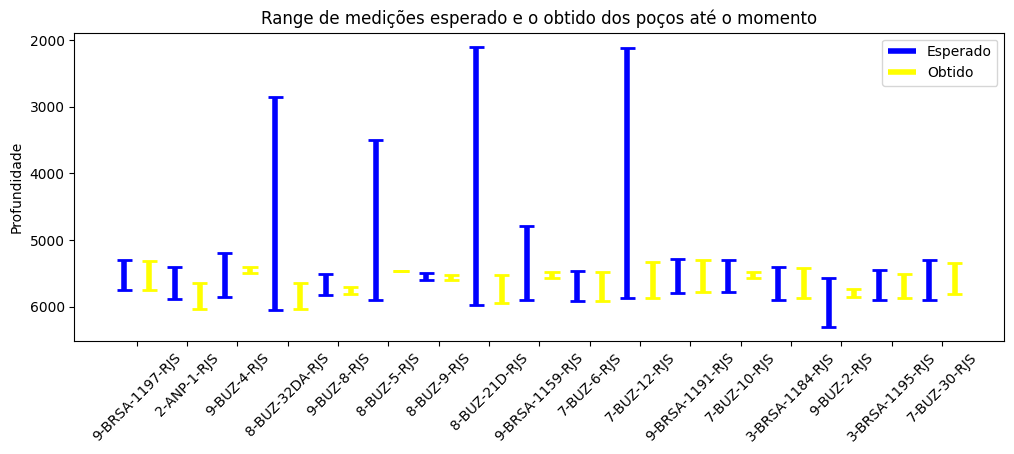

In [67]:
fig = plt.figure(figsize=(12,4))

color_dict = {'expected': 'blue', 'real':'yellow'}

curr_x = 1
wells_with_porosity = real_and_expected_range_for_well.keys()
for well_idx, well in enumerate(wells_with_porosity):
    expected_range, real_range = real_and_expected_range_for_well[well]
    label = True
    expected_label = "Esperado"
    real_label = "Obtido"
    if well_idx > 0:
        label = False
        expected_label = None
        real_label = None
    
    plot_range(expected_range[0], expected_range[1], curr_x, color_dict['expected'], expected_label)
    plot_range(real_range[0], real_range[1], curr_x+1, color_dict['real'], real_label)
    curr_x += 2

plt.gca().invert_yaxis()
plt.ylabel('Profundidade')
plt.title("Range de medições esperado e o obtido dos poços até o momento")
plt.legend()
num_wells = len(wells_with_porosity)
plt.xticks(np.arange(1.5, 2*num_wells, 2), labels=list(wells_with_porosity), rotation=45)
plt.savefig(f"range_esperado_e_informado_pocos_geral.png")
plt.show() 

# Coordenadas dos poços com porosidade até o momento

In [56]:
list(wells_with_porosity)

['9-BRSA-1197-RJS',
 '2-ANP-1-RJS',
 '9-BUZ-4-RJS',
 '8-BUZ-32DA-RJS',
 '9-BUZ-8-RJS',
 '8-BUZ-5-RJS',
 '8-BUZ-9-RJS',
 '8-BUZ-21D-RJS',
 '9-BRSA-1159-RJS',
 '7-BUZ-6-RJS',
 '7-BUZ-12-RJS',
 '9-BRSA-1191-RJS',
 '7-BUZ-10-RJS',
 '3-BRSA-1184-RJS',
 '9-BUZ-2-RJS',
 '3-BRSA-1195-RJS',
 '7-BUZ-30-RJS']

In [59]:
x_present = list()
y_present = list()
x_missing = list()
y_missing = list()
for idx, row in all_wells_info.iterrows():
    well_name = row['Well']
    x_coord = row['x_coord']
    y_coord = row['y_coord']
    if row['Well'] in list(wells_with_porosity):
        x_present.append(x_coord)
        y_present.append(y_coord)
    else:
        x_missing.append(x_coord)
        y_missing.append(y_coord)

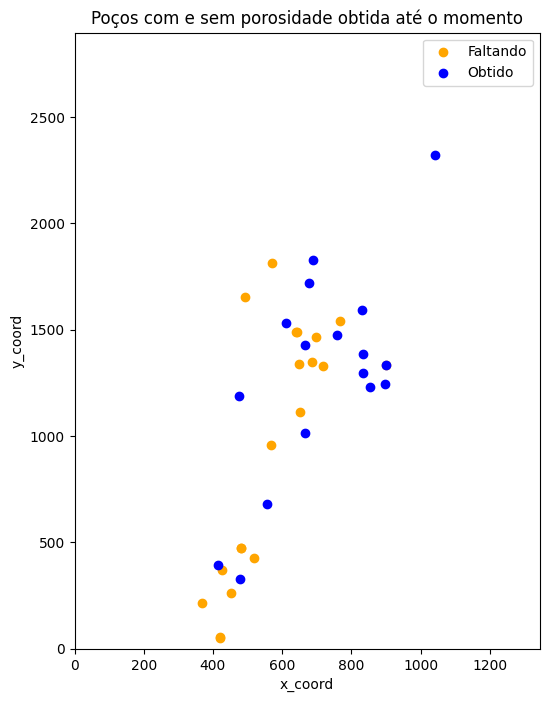

In [65]:
plt.figure(figsize=(6, 8))
y_lim = 2898
x_lim = 1344
plt.ylim((0, y_lim))
plt.xlim((0, x_lim))
plt.scatter(x=x_missing, y=y_missing, label='Faltando', c='orange')
plt.scatter(x=x_present, y=y_present, label='Obtido', c='blue')
plt.title("Poços com e sem porosidade obtida até o momento")
plt.ylabel("y_coord")
plt.xlabel("x_coord")
plt.legend()
plt.savefig("coods_poco_com_por_e_faltando.png")
plt.show()